In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
sales = pd.read_csv('train.csv')

In [3]:
sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [5]:
#Preprocessing the Data
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values(by=['Store', 'Dept', 'Date'])
#aggregating by month instead of weekly
sales['Month'] = sales['Date'].dt.to_period('M')
monthly_sales = sales.groupby(['Month']).agg({'Weekly_Sales':'sum'}).reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

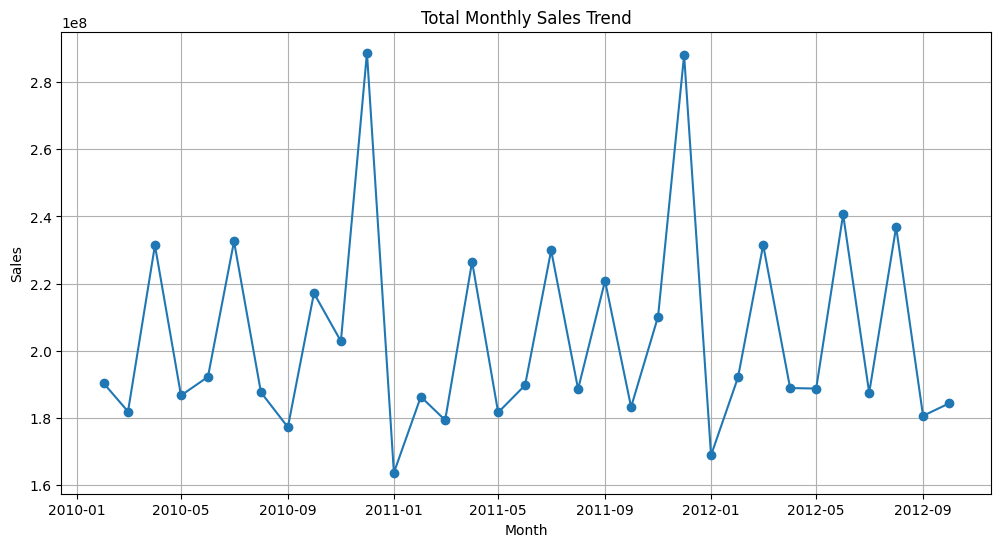

In [6]:
#plotting the monthly trends
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['Weekly_Sales'], marker='o')
plt.title("Total Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

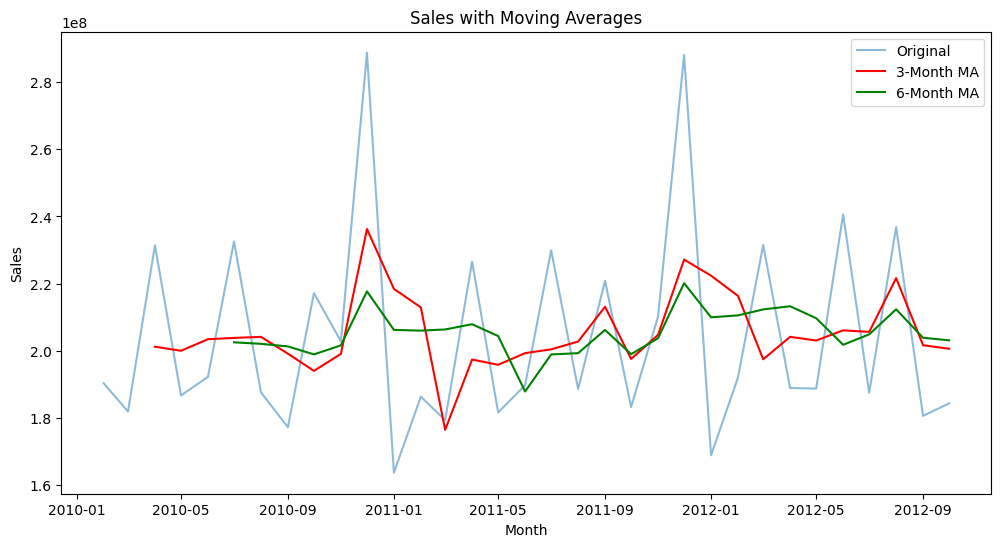

In [7]:
#plotting moving average
monthly_sales['MA_3'] = monthly_sales['Weekly_Sales'].rolling(window=3).mean()
monthly_sales['MA_6'] = monthly_sales['Weekly_Sales'].rolling(window=6).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['Weekly_Sales'], label='Original', alpha=0.5)
plt.plot(monthly_sales['Month'], monthly_sales['MA_3'], label='3-Month MA', color='red')
plt.plot(monthly_sales['Month'], monthly_sales['MA_6'], label='6-Month MA', color='green')
plt.title("Sales with Moving Averages")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.show()

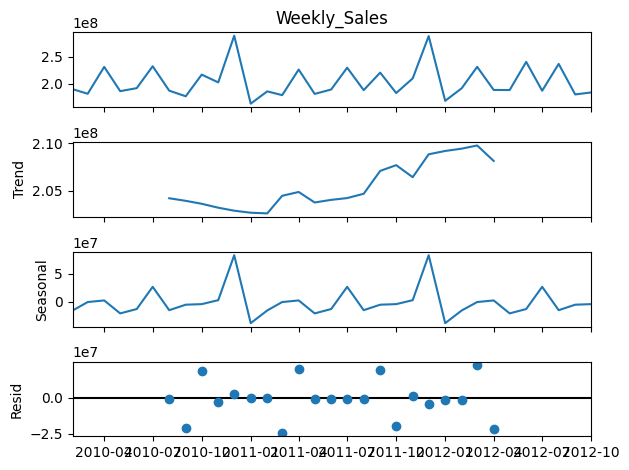

In [8]:
#plotting the seasonal patterns 
monthly_sales.set_index('Month', inplace=True)
decomposition = seasonal_decompose(monthly_sales['Weekly_Sales'], model='additive', period=12)

decomposition.plot()
plt.show()

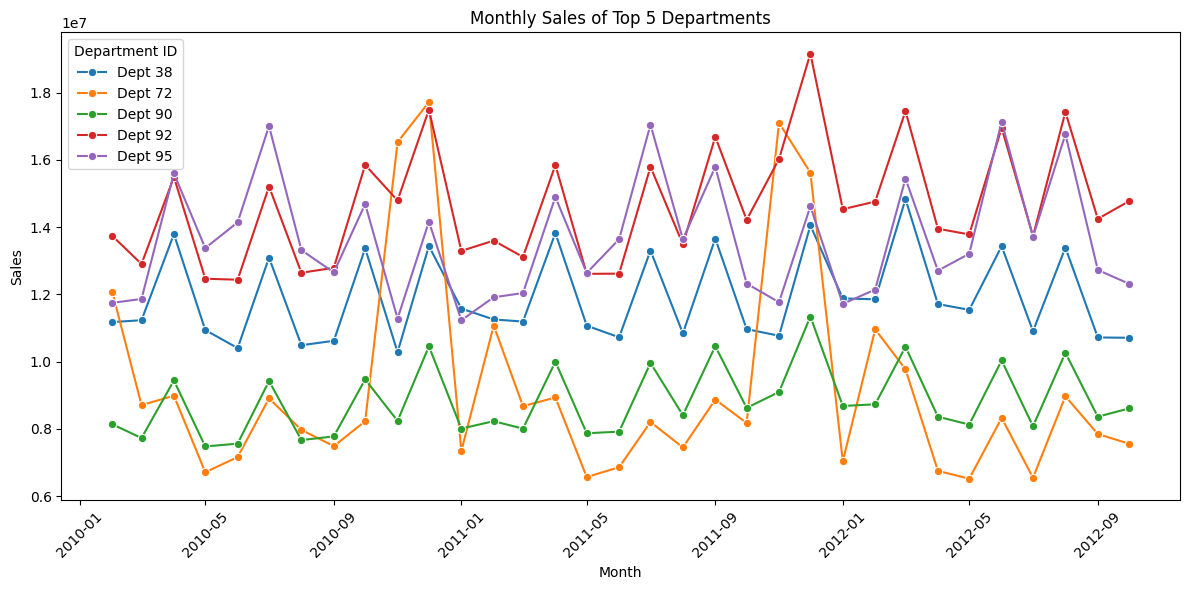

In [9]:
#breaking down revenue by product 
#we used department because the walmart sales forecasting dataset does not provide item-level product identifiers therefore departments are used as a proxyfor product categories 
#total revenue by product is analyzed at the department level which represents aggregated sales of similar product groups  

#creating Month column (period -> timestamp)
sales['Month'] = sales['Date'].dt.to_period('M').dt.to_timestamp()

#aggregating sales by department and month
dept_sales = sales.groupby(['Dept','Month']).agg({'Weekly_Sales':'sum'}).reset_index()

#to increase readability we're only using top 5 departments
top_depts = sales.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False).head(5).index
dept_sales_top = dept_sales[dept_sales['Dept'].isin(top_depts)].copy()

#renaming for better legend
dept_sales_top['DeptLabel'] = dept_sales_top['Dept'].apply(lambda x: f"Dept {x}")  # or use DeptName if available

plt.figure(figsize=(12,6))
sns.lineplot(data=dept_sales_top, x='Month', y='Weekly_Sales', hue='DeptLabel', marker='o', palette='tab10')
plt.title("Monthly Sales of Top 5 Departments")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend(title='Department ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

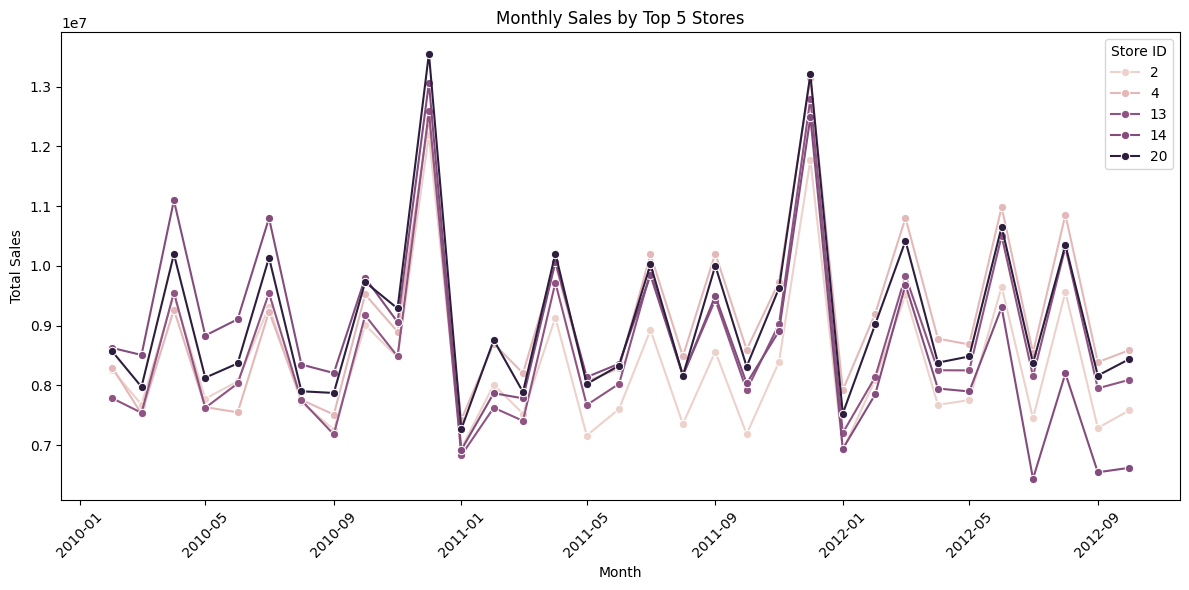

In [10]:
#breaking down revenue by region
#we used store because the walmart sales forecasting dataset does not include the explicit geographic region labels therefore individual stores are used as a proxy for regions 
#total revenue by region is analyzed at the store level over time to compare regional sales 

#top 5 stores
sales['Month'] = sales['Date'].dt.to_period('M').dt.to_timestamp()
store_sales = (
    sales.groupby(['Store', 'Month'])['Weekly_Sales']
    .sum()
    .reset_index()
)
top_stores = (
    sales.groupby('Store')['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
#filtering
store_sales_top = store_sales[store_sales['Store'].isin(top_stores)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=store_sales_top,
    x='Month',
    y='Weekly_Sales',
    hue='Store',
    marker='o'
)

plt.title("Monthly Sales by Top 5 Stores")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title="Store ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

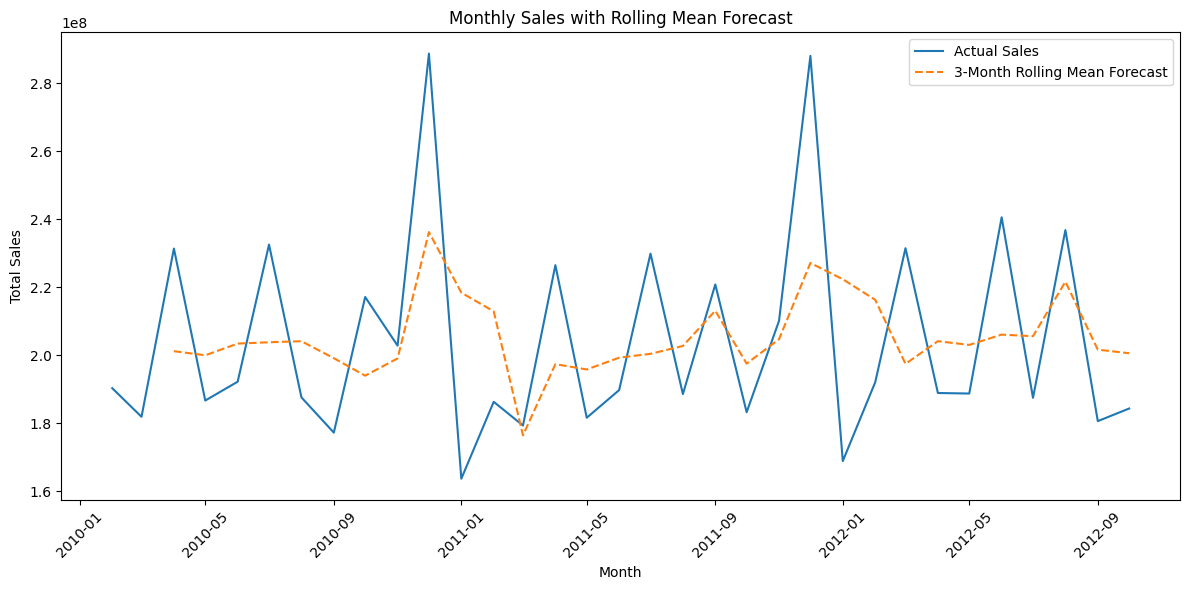

In [12]:
#applying the rolliong mean forecasting to our data
#sorting by time
monthly_sales = monthly_sales.reset_index()
monthly_sales = monthly_sales.sort_values('Month')

#rolling the mean (3-month window)
monthly_sales['Rolling_Mean_3'] = (
    monthly_sales['Weekly_Sales']
    .rolling(window=3)
    .mean()
)

#plotting
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month'],
    monthly_sales['Weekly_Sales'],
    label='Actual Sales'
)

plt.plot(
    monthly_sales['Month'],
    monthly_sales['Rolling_Mean_3'],
    label='3-Month Rolling Mean Forecast',
    linestyle='--'
)

plt.title("Monthly Sales with Rolling Mean Forecast")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### "To ensure interpretability, revenue breakdowns by product and region are visualized using the top-performing departments and stores. Plotting all entities simultaneously results in overplotting and does not provide meaningful insights."

### Key Insights
- From the trends and the moving average plots we can see that sales have a high volatility. 
- Also from the seasonal decomposition plot we can notice clear annual cycility with dominant end-of-year spikes.
- And after breaking down revenue by department we discovered that dept 72 is the outlier leading to the high volatility, In addition to that a correlation of patterns (Almost all five lines move up and down at the exact same time) is also obvious.
- Finally after breaking down revenue by store we can see that all five stores move almost identically.


### A 3-Month Rolling Mean Forecast was applied
It was found insufficient for this dataset due to high seasonal volatility and significant lag in predicting peak periods 